# Final Rapor — ECoG Faces vs Houses (Miller 2019, `faces_basic`)

Bu notebook, 01-07 numaralı notebook'larda yapılan tüm analizleri tek bir
akışta özetler: veri seti → ön işleme → etiketleme → özellik çıkarımı →
sınıflandırma → değerlendirme → derin öğrenme → SOTA karşılaştırması.

**Kaynak notebook'lar:** `01_eda.ipynb`, `02_preprocessing.ipynb`,
`03_label_alignment.ipynb`, `04_feature_extraction.ipynb`,
`05_classification.ipynb`, `06_evaluation.ipynb`, `07_deep_learning.ipynb`.
**Kaynak raporlar:** `reports/baseline_results.csv`,
`reports/deep_results.csv`, `reports/final_evaluation.md`,
`reports/sota_comparison.md`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sys.path.insert(0, str(Path("..").resolve()))

from src.preprocessing.preprocess import list_available_patients

PATIENTS = list_available_patients()
baseline_df = pd.read_csv("../reports/baseline_results.csv")
deep_df = pd.read_csv("../reports/deep_results.csv")

## 1. Veri seti tanıtımı

**Kaynak:** Miller, K.J. (2019). *A library of human electrocorticographic
data and analyses*, Stanford Digital Repository (PURL:
https://purl.stanford.edu/zk881ps0522, CC BY-SA 4.0). Kullanılan görev:
**`faces_basic`** ("Faces vs Houses") — 400ms süreyle art arda sunulan
yüz/ev görselleri (Miller ve ark. 2016, *PLoS Comp. Biol.*).

**14 hasta**, her biri kendi elektrot montajıyla (grid/strip sayısı ve
yerleşimi hastadan hastaya farklı — klinik epilepsi cerrahisi amaçlı
implantasyona bağlı). Örnekleme hızı tüm hastalarda **1000 Hz** sabit.

In [2]:
summary_rows = []
for pid in PATIENTS:
    anat = pd.read_csv(f"../data/processed/{pid}/{pid}_anatomical_labels.csv")
    roi = anat[anat["is_temporal"] | anat["is_fusiform"] | anat["is_occipital"]]
    summary_rows.append({
        "hasta": pid,
        "toplam_kanal": len(anat) + 0,  # kept-channel sayısı (bad channels çıkarılmış)
        "roi_kanal": len(roi),
        "fusiform_kanal": int(roi["is_fusiform"].sum()),
        "temporal_kanal": int(roi["is_temporal"].sum()),
        "occipital_kanal": int(roi["is_occipital"].sum()),
    })

dataset_summary_df = pd.DataFrame(summary_rows).sort_values("toplam_kanal")
dataset_summary_df

,hasta,toplam_kanal,roi_kanal,fusiform_kanal,temporal_kanal,occipital_kanal
3,de,30,20,2,9,9
5,ha,38,19,4,11,4
11,rr,38,32,7,21,4
12,wc,38,18,6,5,7
1,ap,39,28,7,21,0
10,rn,42,33,5,18,10
0,aa,44,28,4,20,4
2,ca,49,23,4,16,3
4,fp,49,7,0,5,2
7,jm,55,12,3,7,2


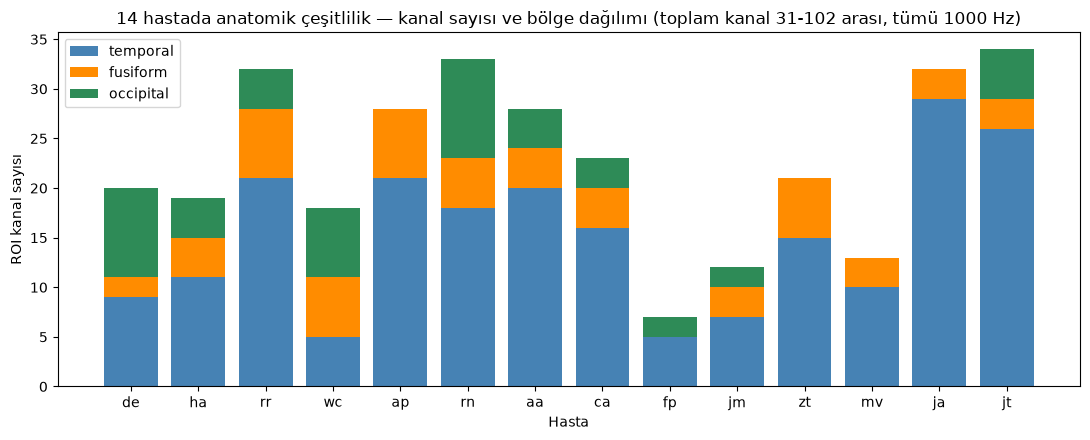

fp hastasında fusiform kanal: 0 (bu hasta FFA analizlerinde özel not ile ele alınıyor)


In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(dataset_summary_df))
ax.bar(x, dataset_summary_df["temporal_kanal"], label="temporal", color="steelblue")
ax.bar(x, dataset_summary_df["fusiform_kanal"], bottom=dataset_summary_df["temporal_kanal"],
       label="fusiform", color="darkorange")
ax.bar(x, dataset_summary_df["occipital_kanal"],
       bottom=dataset_summary_df["temporal_kanal"] + dataset_summary_df["fusiform_kanal"],
       label="occipital", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(dataset_summary_df["hasta"])
ax.set_xlabel("Hasta"); ax.set_ylabel("ROI kanal sayısı")
ax.set_title("14 hastada anatomik çeşitlilik — kanal sayısı ve bölge dağılımı "
             f"(toplam kanal 31-102 arası, tümü 1000 Hz)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"fp hastasında fusiform kanal: {dataset_summary_df.set_index('hasta').loc['fp','fusiform_kanal']} "
      "(bu hasta FFA analizlerinde özel not ile ele alınıyor)")

## 2. Analiz akışı (pipeline)

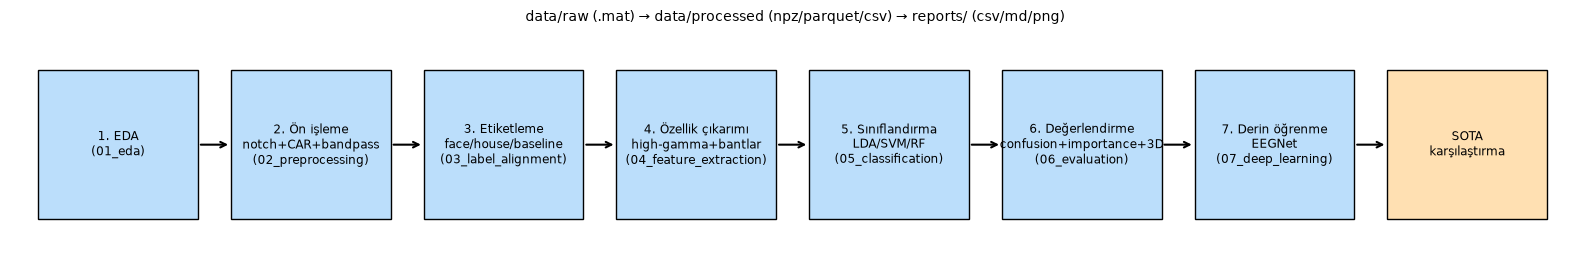

In [4]:
stages = [
    "1. EDA\n(01_eda)",
    "2. Ön işleme\nnotch+CAR+bandpass\n(02_preprocessing)",
    "3. Etiketleme\nface/house/baseline\n(03_label_alignment)",
    "4. Özellik çıkarımı\nhigh-gamma+bantlar\n(04_feature_extraction)",
    "5. Sınıflandırma\nLDA/SVM/RF\n(05_classification)",
    "6. Değerlendirme\nconfusion+importance+3D\n(06_evaluation)",
    "7. Derin öğrenme\nEEGNet\n(07_deep_learning)",
    "SOTA\nkarşılaştırma",
]

fig, ax = plt.subplots(figsize=(16, 2.8))
box_w, box_h, gap = 1.7, 1.1, 0.35
for i, stage in enumerate(stages):
    x0 = i * (box_w + gap)
    color = "#ffe0b2" if "SOTA" in stage else "#bbdefb"
    ax.add_patch(plt.Rectangle((x0, 0), box_w, box_h, facecolor=color, edgecolor="black"))
    ax.text(x0 + box_w / 2, box_h / 2, stage, ha="center", va="center", fontsize=8.5)
    if i < len(stages) - 1:
        ax.annotate("", xy=(x0 + box_w + gap, box_h / 2), xytext=(x0 + box_w, box_h / 2),
                     arrowprops=dict(arrowstyle="->", lw=1.5))

ax.set_xlim(-0.3, len(stages) * (box_w + gap))
ax.set_ylim(-0.3, box_h + 0.3)
ax.axis("off")
ax.set_title("data/raw (.mat) → data/processed (npz/parquet/csv) → reports/ (csv/md/png)", fontsize=10)
plt.tight_layout()
plt.show()

## 3. Bilimsel bulgu: Fusiform Face Area (FFA) doğrulaması

Üç bağımsız yöntem aynı sonuca işaret ediyor:

1. **Tek-kanal t-testi** (high-gamma, face vs house) — `ap` hastasında en
   güçlü 3 kanal (t=10.3, p=1.3×10⁻²¹ dahil) tamamen fusiform gyrus'ta.
2. **Çok-kanallı Random Forest feature importance** — 14 hastanın
   **13'ünde**, modelin en önemli bulduğu kanalın anatomik bölgesi
   t-testinkiyle birebir örtüşüyor (ortalama Spearman ρ=0.629).
3. **3D kortikal yüzey görselleştirmesi** — `ap` ve `zt` hastalarında en
   yüksek importance'lı elektrotlar görsel olarak fusiform gyrus'ta
   kümeleniyor.

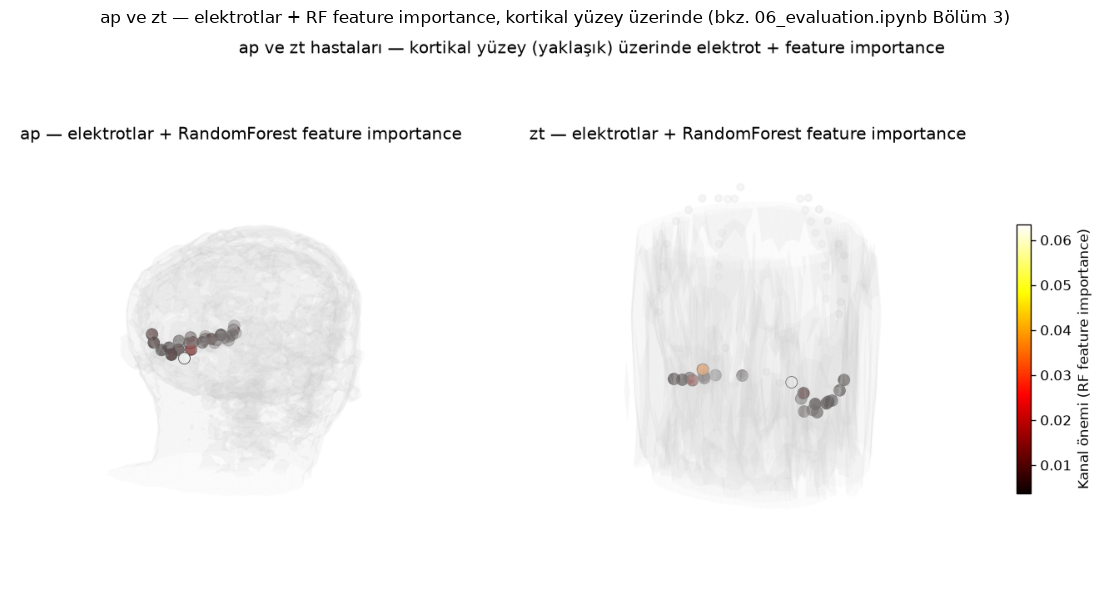

In [5]:
img = mpimg.imread("../reports/figures/electrodes_on_cortex_ap_zt.png")
fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(img)
ax.axis("off")
ax.set_title("ap ve zt — elektrotlar + RF feature importance, kortikal yüzey üzerinde "
             "(bkz. 06_evaluation.ipynb Bölüm 3)")
plt.tight_layout()
plt.show()

**Fusiform gyrus'ta elektrotu olan hastalarda** (`ap`, `ca`, `ja`, `mv`,
`zt`) face-selektivite tutarlı şekilde en güçlü ve en çok fusiform
kanallara atfediliyor — literatürdeki FFA bulgusunun bu ECoG veri
setinde sağlam bir şekilde yeniden üretildiğini gösteriyor. `fp` hastası
(fusiform elektrotu **yok**) bu üç yöntemin hiçbirinde FFA kanıtı
üretmiyor — occipital-kaynaklı, düşük-seviye bir görsel ayrım gösteriyor
(bkz. Bölüm 7, Sınırlamalar).

## 4. Sınıflandırma sonuçları — sinyal gücü ↔ accuracy ilişkisi

14 hasta × 3 model (LDA, Linear SVM, Random Forest), zamansal-blok
`GroupKFold(5)` + 200-permütasyonlu anlamlılık testi.

In [6]:
print("Model bazlı ortalama performans (14 hasta):")
print(baseline_df.groupby("model")[["accuracy", "macro_f1", "roc_auc"]].mean().round(3))
print()
n_sig = (baseline_df["permutation_p_value"] < 0.01).sum()
print(f"p<0.01'de anlamlı (hasta, model) kombinasyonu: {n_sig}/{len(baseline_df)}")

Model bazlı ortalama performans (14 hasta):
              accuracy  macro_f1  roc_auc
model                                    
LDA              0.856     0.854    0.915
Linear_SVM       0.830     0.828    0.888
RandomForest     0.876     0.876    0.924

p<0.01'de anlamlı (hasta, model) kombinasyonu: 42/42


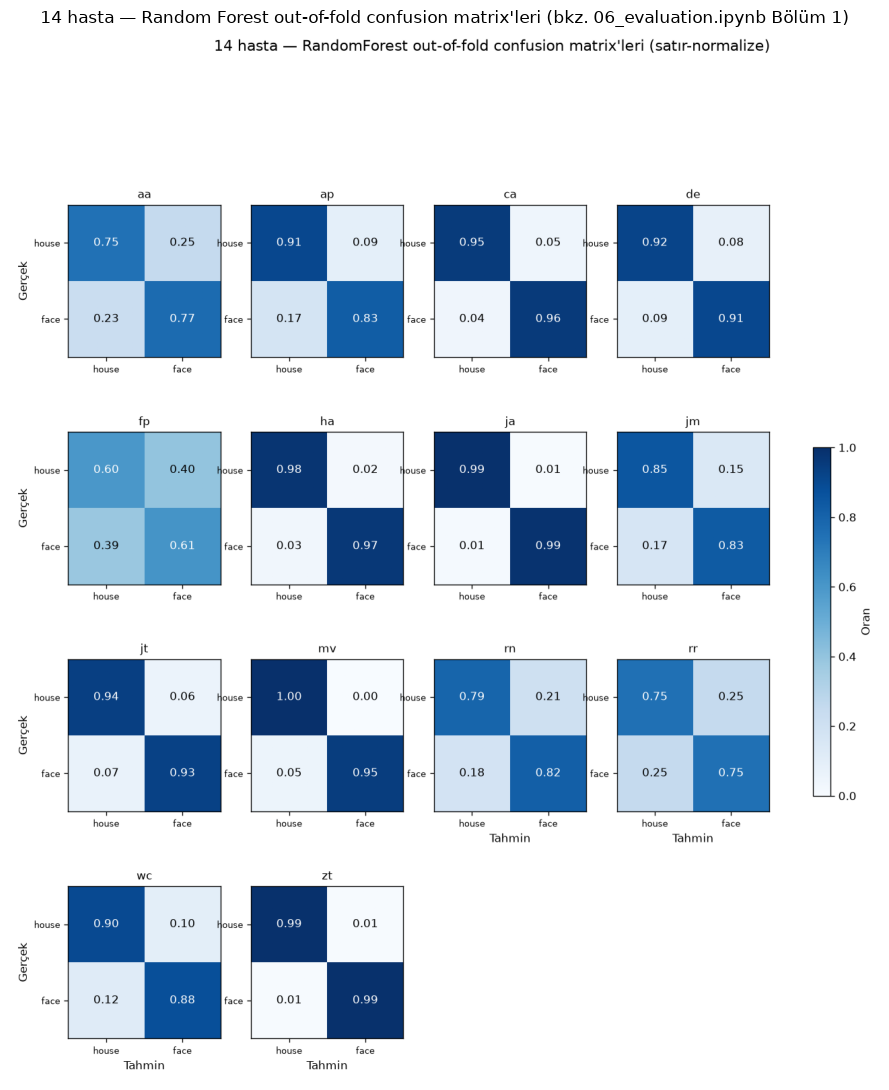

In [7]:
img = mpimg.imread("../reports/figures/confusion_matrix_grid.png")
fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(img)
ax.axis("off")
ax.set_title("14 hasta — Random Forest out-of-fold confusion matrix'leri "
             "(bkz. 06_evaluation.ipynb Bölüm 1)")
plt.tight_layout()
plt.show()

**Sinyal gücü ↔ accuracy korelasyonu: r=0.895** (bkz.
`05_classification.ipynb` Bölüm 3) — tek-kanal t-testi etki büyüklüğü
(|t|) ile çok-kanallı en-iyi-model accuracy'si arasında güçlü pozitif
ilişki. "Çok güçlü" sinyal kategorisindeki hastalar ortalama %97.1,
"orta" kategori %82.1, "zayıf" kategori (`rr`) %75.9 accuracy'ye
ulaşıyor — beklenen "güçlü sinyal → yüksek doğruluk" ilişkisi doğrulandı.

## 5. Derin öğrenme bulgusu — EEGNet, zayıf-sinyal hastalarında avantajlı

**⚠️ Örneklem uyarısı: n=5 hasta.** Bu bölümdeki EEGNet sonuçları yalnızca
5 temsili hastada (hesaplama maliyeti nedeniyle) elde edildi — 14
hastanın tamamında değil. Bu nedenle bulgu **kesin bir genel-geçer sonuç
değil, ileri araştırma için bir hipotezdir**.

In [8]:
signal_strength = {"ap": "güçlü", "zt": "güçlü", "aa": "orta", "fp": "zayıf", "rr": "zayıf"}
rep_patients = list(signal_strength.keys())

best_baseline = (
    baseline_df[baseline_df["patient"].isin(rep_patients)]
    .groupby("patient")["accuracy"].max()
)
compare_df = pd.DataFrame({
    "hasta": rep_patients,
    "sinyal_kategorisi": [signal_strength[p] for p in rep_patients],
    "en_iyi_baseline_acc": [best_baseline[p] for p in rep_patients],
    "eegnet_acc": [deep_df.set_index("patient").loc[p, "accuracy"] for p in rep_patients],
})
compare_df["fark"] = compare_df["eegnet_acc"] - compare_df["en_iyi_baseline_acc"]
compare_df.sort_values("fark", ascending=False)

,hasta,sinyal_kategorisi,en_iyi_baseline_acc,eegnet_acc,fark
4,rr,zayıf,0.758738,0.860000,0.101262
3,fp,zayıf,0.663280,0.733333,0.070053
2,aa,orta,0.758289,0.756667,-0.001622
1,zt,güçlü,0.993939,0.986667,-0.007273
0,ap,güçlü,0.868227,0.833333,-0.034893


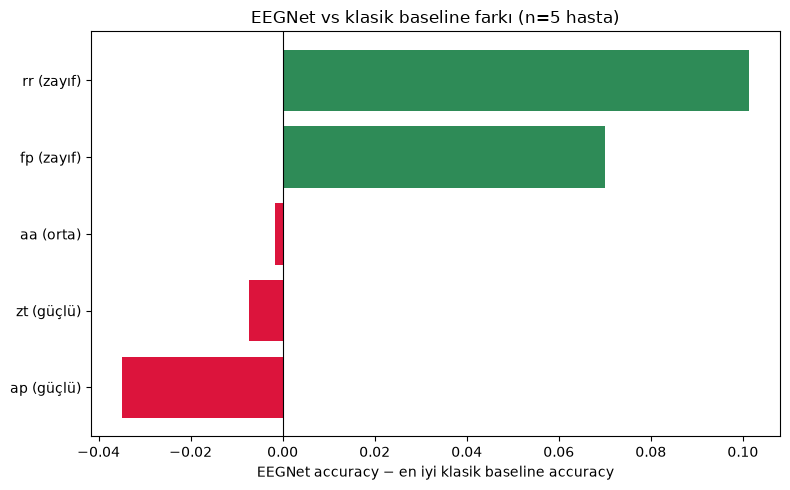

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["seagreen" if f > 0 else "crimson" for f in compare_df["fark"]]
ax.barh(compare_df["hasta"] + " (" + compare_df["sinyal_kategorisi"] + ")",
        compare_df["fark"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("EEGNet accuracy − en iyi klasik baseline accuracy")
ax.set_title("EEGNet vs klasik baseline farkı (n=5 hasta)")
plt.tight_layout()
plt.show()

EEGNet, zayıf-sinyal hastalarında (`fp`: +0.070, `rr`: +0.101) klasik
baseline'ları geçiyor; güçlü-sinyal hastalarında (`ap`: -0.035, `zt`:
-0.007) hafifçe geride kalıyor. Olası açıklama: ham zaman-serisi, elle
tasarlanmış 5 sabit spektral banda sığmayan faz/ERP bilgisini
yakalayabiliyor. **Bu örüntünün 14 hastanın tamamında geçerli olup
olmadığı doğrulanmadı** — n=5 ile istatistiksel güç sınırlı.

## 6. SOTA karşılaştırma (dürüst metodolojik çerçeve)

Tam detay: `reports/sota_comparison.md`. Özet:

- **EEGNet (Lawhern ve ark. 2018)**: orijinal makale **P300, ERN, MRCP,
  SMR** paradigmalarında, **yüzeysel EEG** üzerinde test edilmiş — ECoG
  değil, face/house gibi bir görsel kategori görevi yok. Bizim
  çalışmamıza yalnızca **mimari** (kompakt depthwise/separable CNN)
  olarak aktarıldı; **hiçbir sayısal accuracy/AUC karşılaştırması
  yapılmadı**.
- **HTNet (Peterson ve ark. 2021)**: asıl benchmark görevi **kol hareketi
  decoding'i (move vs rest)**, face/house değil; temel katkısı
  **hastalar-arası genelleme için elektrot-projeksiyon katmanı**. Bizim
  çalışmamız yalnızca **within-subject** (hastalar-arası genelleme
  denenmedi); HTNet'ten yalnızca **metodolojik fikir** referans alındı
  (elektrot yerleşimi hastadan hastaya değiştiği için gelecekte
  uygulanabilecek doğal bir sonraki adım olarak not edildi).
- **Sonuç**: iki makale de farklı görev/modalite/genelleme rejimi
  kullandığından **doğrudan sayısal kıyas yapılmadı** — yalnızca
  yöntemsel emsal olarak değerlendirildi.

## 7. Sınırlamalar

1. **Within-subject yaklaşım**: Her hasta ayrı ayrı modellendi;
   hastalar-arası genelleme (cross-subject) hiç denenmedi. Elektrot
   yerleşimi (31-102 kanal, hastadan hastaya farklı montaj) bu tür bir
   genellemeyi doğrudan zorlaştırıyor (bkz. HTNet'in çözmeye çalıştığı
   tam olarak bu problem).
2. **`fp` hastasının fusiform eksikliği**: Bu hastada fusiform gyrus'ta
   hiç elektrot yok (yalnızca 7 occipital-ağırlıklı ROI kanalı). Bu
   hastadaki tüm sınıflandırma/görselleştirme sonuçları (en düşük
   accuracy'ler arasında, en yüksek confusion oranı) FFA kanıtı olarak
   yorumlanmadı; occipital-kaynaklı düşük-seviye bir görsel ayrımı
   yansıtıyor olabilir.
3. **Yaklaşık kortikal mesh**: 3D görselleştirmede kullanılan yüzey,
   veri setinde hazır bir pial/kortikal mesh (FreeSurfer/SPM çıktısı)
   bulunmadığından, ham T1 `.nii` hacminden Otsu eşiğine dayalı
   marching-cubes ile üretildi — gerçek bir kortikal yüzey
   rekonstrüksiyonu değil, yalnızca göreli elektrot konumu için bir
   yaklaşıklık.
4. **5-hasta derin öğrenme örneklemi**: EEGNet sonuçları yalnızca 5
   temsili hastada (hesaplama maliyeti nedeniyle) elde edildi. "Zayıf
   sinyalde EEGNet avantajı" bulgusu, 14 hastanın tamamında
   doğrulanmadığı için **ön-bulgu / hipotez** niteliğinde, kesin bir
   sonuç değil.
5. **Kısa event penceresi (400ms)**: theta bandı (4-8 Hz) gibi düşük
   frekans bantları için Welch PSD çözünürlüğü kaba (~2.5 Hz) — bant-güç
   tahminleri bu bantlarda daha az güvenilir olabilir.
6. **Permütasyon testi yalnızca klasik modellerde**: EEGNet için
   hesaplama maliyeti nedeniyle 200-permütasyonlu anlamlılık testi
   çalıştırılmadı; derin öğrenme sonuçlarının istatistiksel anlamlılığı
   doğrudan test edilmedi.

## Genel Sonuç

Bu proje, Miller (2019) `faces_basic` ECoG veri setinde, ham `.mat`
dosyalarından başlayarak uçtan uca bir analiz hattı kurdu ve
literatürdeki **fusiform face area (FFA)** bulgusunu üç bağımsız yöntemle
(t-test, model feature importance, 3D görselleştirme) tutarlı bir şekilde
yeniden üretti. Klasik makine öğrenmesi modelleri (özellikle Random
Forest) within-subject face/house ayrımında güçlü ve istatistiksel olarak
anlamlı performans gösterdi (ort. accuracy 0.83-0.88); sinyal gücü ile
sınıflandırma doğruluğu arasındaki ilişki de (r=0.895) doğrulandı. Sınırlı
bir örneklemde test edilen EEGNet, zayıf-sinyal hastalarında umut verici
ama doğrulanmamış bir avantaj gösterdi. Tüm bulgular, veri setinin ve
yöntemin sınırlamaları (within-subject, `fp`'nin fusiform eksikliği,
yaklaşık kortikal mesh, küçük derin-öğrenme örneklemi) açıkça belirtilerek
raporlandı.